In [1]:
import numpy as np
from tensorflow.keras.models import save_model, load_model, Model
from tensorflow.keras.layers import Input, Dropout, BatchNormalization, LeakyReLU, concatenate
from tensorflow.keras.layers import Conv2D, MaxPooling2D, AveragePooling2D, Conv2DTranspose
import h5py 
import cv2
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import segmentation_models as sm
import tensorflow.keras
# from tensorflow import keras
# from tensorflow.keras.layers import Input

Segmentation Models: using `keras` framework.


In [14]:
# 读取训练集
fh5 = h5py.File(r'E:\data paper1\img train PolypGen+CVC\img Highlights processing FMM\imgandmasks_Highlights_processing_percentile=99.5.h5','r')
#fh5 = h5py.File(r'D:\PolypGen+CVCtrain_imgandmasks.h5','r')
img_png_x = fh5['img']
img_png_x = np.array(img_png_x)
#img_gray_c = fh5['img_gray']
#img_gray_c = np.array(img_gray_c)
mask_x = fh5['masks']
mask_x = np.array(mask_x)

In [15]:
img_png_x.shape

(2987, 288, 384, 3)

In [16]:
img_png_x.max()

1.0

In [17]:
# 归一化操作
# imgmax = img_png_x.max()

In [18]:
# img_png_x = img_png_x/(imgmax)

In [19]:
#查看是否归一化
# img_png_x.max()

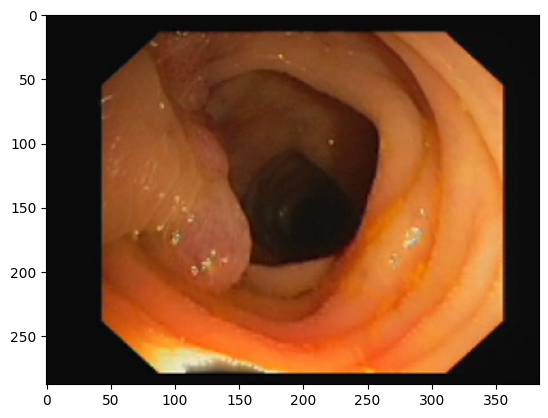

In [20]:
plt.imshow(img_png_x[10])

In [21]:
mask_x.max()
mask_x .shape

(2987, 288, 384)

In [22]:
mask_x  = mask_x .reshape(len(mask_x),288, 384, 1)
mask_x .shape

(2987, 288, 384, 1)

In [23]:
# mask_x = mask_x/255

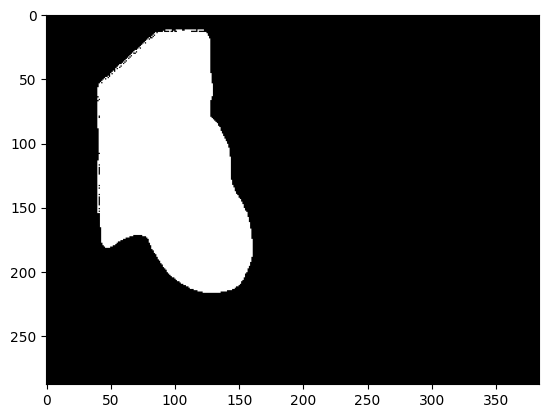

In [24]:
plt.imshow(mask_x[10],'gray')

In [25]:
#查看是否归一化
mask_x.max()

1.0

In [26]:
# mask_x[0]

In [27]:
# 划分训练集与验证集
# 划分训练集与验证集
# 划分训练集与验证集
# T_img_png_x
# T_mask_x
# V_img
# V_mask

In [28]:
# -----------------------------------------------------------------
# 从txt文件读取并恢复为NumPy数组
# -----------------------------------------------------------------
# 读取训练集
# Train = np.loadtxt('E:\wujieyu\img train PolypGen+CVC\Train.txt', dtype=int)
Train = np.loadtxt('E:\polyp-learningbased\Train.txt', dtype=int)
# 读取验证集
# Val = np.loadtxt('E:\wujieyu\img train PolypGen+CVC\Val.txt', dtype=int)
Val = np.loadtxt('E:\polyp-learningbased\Val.txt', dtype=int)

In [29]:
Train.shape

(2539,)

In [30]:
Val.shape

(448,)

In [31]:
# -----------------------------------------------------------------
# 按索引划分图像数据
# -----------------------------------------------------------------
# 划分训练集（T_img_png_x）和验证集（V_img）
T_img = img_png_x[Train]
V_img = img_png_x[Val]

In [32]:
T_img.shape

(2539, 288, 384, 3)

In [33]:
V_img.shape

(448, 288, 384, 3)

In [34]:
T_mask = mask_x[Train]
V_mask = mask_x[Val]

In [35]:
T_mask.shape

(2539, 288, 384, 1)

In [36]:
V_mask.shape

(448, 288, 384, 1)

(-0.5, 383.5, 287.5, -0.5)

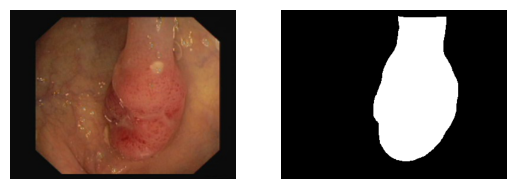

In [37]:
# 查看训练集集
a = 10
plt.figure()
plt.subplot(121),plt.imshow(T_img[a])
plt.axis('off')
plt.subplot(122),plt.imshow(T_mask[a],'gray')
plt.axis('off')

(-0.5, 383.5, 287.5, -0.5)

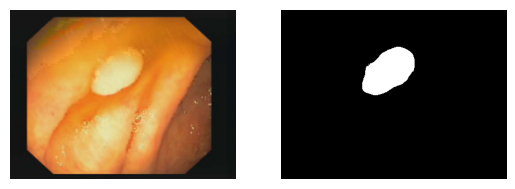

In [38]:
# 查看验证集
a = 10
plt.figure()
plt.subplot(121),plt.imshow(V_img[a])
plt.axis('off')
plt.subplot(122),plt.imshow(V_mask[a],'gray')
plt.axis('off')

In [39]:
import tensorflow as tf
from tensorflow.keras import layers, models

# =========================================================
# 1) Transformer 相关模块
# =========================================================

class AddPositionEmbs(layers.Layer):
    def build(self, input_shape):
        # input_shape: [B, N, C]
        self.pos_emb = self.add_weight(
            name="pos_embedding",
            shape=(1, input_shape[1], input_shape[2]),
            initializer=tf.keras.initializers.RandomNormal(stddev=0.06),
            trainable=True
        )

    def call(self, x):
        return x + self.pos_emb


class MultiHeadSelfAttention(layers.Layer):
    def __init__(self, hidden_size, num_heads, attn_dropout=0.0):
        super().__init__()
        assert hidden_size % num_heads == 0, "hidden_size must be divisible by num_heads"
        self.hidden_size = hidden_size
        self.num_heads = num_heads
        self.head_dim = hidden_size // num_heads
        self.attn_dropout = layers.Dropout(attn_dropout)

        self.q_dense = layers.Dense(hidden_size)
        self.k_dense = layers.Dense(hidden_size)
        self.v_dense = layers.Dense(hidden_size)
        self.out_dense = layers.Dense(hidden_size)

    def _split_heads(self, x):
        # [B, N, C] -> [B, H, N, D]
        b = tf.shape(x)[0]
        n = tf.shape(x)[1]
        x = tf.reshape(x, [b, n, self.num_heads, self.head_dim])
        return tf.transpose(x, [0, 2, 1, 3])

    def call(self, x, training=None):
        q = self._split_heads(self.q_dense(x))
        k = self._split_heads(self.k_dense(x))
        v = self._split_heads(self.v_dense(x))

        scale = tf.cast(self.head_dim, x.dtype) ** -0.5
        attn = tf.matmul(q, k, transpose_b=True) * scale
        attn = tf.nn.softmax(attn, axis=-1)
        attn = self.attn_dropout(attn, training=training)

        out = tf.matmul(attn, v)                # [B, H, N, D]
        out = tf.transpose(out, [0, 2, 1, 3])  # [B, N, H, D]

        b = tf.shape(out)[0]
        n = tf.shape(out)[1]
        out = tf.reshape(out, [b, n, self.hidden_size])
        out = self.out_dense(out)
        return out

def gelu_fn(x):
    if hasattr(tf.keras.activations, "gelu"):
        return tf.keras.activations.gelu(x, approximate=False)
    return 0.5 * x * (1.0 + tf.tanh(
        tf.sqrt(2.0 / 3.141592653589793) * (x + 0.044715 * tf.pow(x, 3))
    ))


class TransformerBlock(layers.Layer):
    def __init__(self, hidden_size, num_heads, mlp_dim, dropout=0.1):
        super().__init__()
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.attn = MultiHeadSelfAttention(hidden_size, num_heads, attn_dropout=dropout)
        self.drop1 = layers.Dropout(dropout)

        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.mlp = models.Sequential([
            layers.Dense(mlp_dim),
            layers.Lambda(gelu_fn),
            layers.Dropout(dropout),
            layers.Dense(hidden_size),
            layers.Dropout(dropout),
        ])

    def call(self, x, training=None):
        x = x + self.drop1(self.attn(self.norm1(x), training=training), training=training)
        x = x + self.mlp(self.norm2(x), training=training)
        return x


# =========================================================
# 2) Decoder 相关模块
# =========================================================

class Conv2DReLU(layers.Layer):
    def __init__(self, filters, kernel_size, strides=1, padding="same", use_bn=True):
        super().__init__()
        self.conv = layers.Conv2D(
            filters=filters,
            kernel_size=kernel_size,
            strides=strides,
            padding=padding,
            use_bias=not use_bn,
            kernel_initializer="he_normal"
        )
        self.bn = layers.BatchNormalization() if use_bn else None
        self.relu = layers.ReLU()

    def call(self, x, training=None):
        x = self.conv(x)
        if self.bn is not None:
            x = self.bn(x, training=training)
        x = self.relu(x)
        return x


class DecoderBlock(layers.Layer):
    def __init__(self, filters):
        super().__init__()
        self.up = layers.UpSampling2D(size=2, interpolation="bilinear")
        self.conv1 = Conv2DReLU(filters, 3)
        self.conv2 = Conv2DReLU(filters, 3)

    def call(self, x, skip=None, training=None):
        x = self.up(x)
        if skip is not None:
            x = tf.concat([x, skip], axis=-1)
        x = self.conv1(x, training=training)
        x = self.conv2(x, training=training)
        return x


class DecoderCup(layers.Layer):
    def __init__(self, decoder_channels=(256, 128, 64, 16), n_skip=3):
        super().__init__()
        self.n_skip = n_skip
        self.conv_more = Conv2DReLU(512, 3)
        self.blocks = [DecoderBlock(ch) for ch in decoder_channels]

    def call(self, hidden_states, features=None, training=None):
        x = self.conv_more(hidden_states, training=training)
        for i, block in enumerate(self.blocks):
            skip = features[i] if (features is not None and i < self.n_skip) else None
            x = block(x, skip=skip, training=training)
        return x


class SegmentationHead(layers.Layer):
    def __init__(self, num_classes=1, kernel_size=1, final_act=None):
        super().__init__()
        self.conv = layers.Conv2D(num_classes, kernel_size, padding="same")
        self.final_act = layers.Activation(final_act) if final_act is not None else None

    def call(self, x):
        x = self.conv(x)
        if self.final_act is not None:
            x = self.final_act(x)
        return x


# =========================================================
# 3) Backbone
# =========================================================

def build_backbone(input_shape=(288, 384, 3), weights="imagenet", freeze_backbone=True):
    inputs = layers.Input(shape=input_shape)

    base = tf.keras.applications.ResNet50V2(
        include_top=False,
        weights=weights,
        input_tensor=inputs
    )

    c1 = base.get_layer("conv1_conv").output                  # /2
    c2 = base.get_layer("conv2_block3_preact_relu").output    # /4
    c3 = base.get_layer("conv3_block4_preact_relu").output    # /8
    c4 = base.get_layer("conv4_block6_preact_relu").output    # /16

    backbone = models.Model(inputs=inputs, outputs=[c1, c2, c3, c4], name="resnet50v2_backbone")

    if freeze_backbone:
        backbone.trainable = False

    return backbone


# =========================================================
# 4) 构建完整 TransUNet
# =========================================================

def build_transunet(
    input_shape=(288, 384, 3),
    num_classes=1,
    final_act="sigmoid",
    hidden_size=768,
    num_heads=12,
    mlp_dim=3072,
    num_transformer_layers=12,
    transformer_dropout=0.1,
    decoder_channels=(256, 128, 64, 16),
    n_skip=3,
    backbone_weights="imagenet",
    freeze_backbone=True,
):
    inputs = layers.Input(shape=input_shape)

    # Backbone features
    c1, c2, c3, c4 = build_backbone(
        input_shape=input_shape,
        weights=backbone_weights,
        freeze_backbone=freeze_backbone
    )(inputs)

    # skip features 顺序和 decoder 对齐：高层 -> 低层
    features = [c3, c2, c1]

    # -----------------------------------------------------
    # Patch Embedding
    # 这里直接把 c4 每个空间位置映射成 token
    # 对于 288x384 输入，c4 一般是 18x24
    # -----------------------------------------------------
    x = layers.Conv2D(
        filters=hidden_size,
        kernel_size=1,
        strides=1,
        padding="same",
        name="embedding"
    )(c4)

    h = x.shape[1]
    w = x.shape[2]
    if h is None or w is None:
        raise ValueError("Static spatial shape is required. Please provide a fixed input_shape.")

    x = layers.Reshape((h * w, hidden_size))(x)
    x = AddPositionEmbs()(x)
    x = layers.Dropout(transformer_dropout)(x)

    # -----------------------------------------------------
    # Transformer Encoder
    # -----------------------------------------------------
    for _ in range(num_transformer_layers):
        x = TransformerBlock(
            hidden_size=hidden_size,
            num_heads=num_heads,
            mlp_dim=mlp_dim,
            dropout=transformer_dropout
        )(x)

    x = layers.LayerNormalization(epsilon=1e-6)(x)

    # token -> feature map
    x = layers.Reshape((h, w, hidden_size))(x)

    # -----------------------------------------------------
    # Decoder
    # -----------------------------------------------------
    x = DecoderCup(
        decoder_channels=decoder_channels,
        n_skip=n_skip
    )(x, features=features)

    # -----------------------------------------------------
    # Segmentation Head
    # -----------------------------------------------------
    x = SegmentationHead(
        num_classes=num_classes,
        kernel_size=1,
        final_act=None
    )(x)

    # 最后 resize 回原图大小
    x = layers.Lambda(
        lambda t: tf.image.resize(t[0], tf.shape(t[1])[1:3], method="bilinear"),
        name="final_resize"
    )([x, inputs])

    if final_act is not None:
        x = layers.Activation(final_act)(x)

    return models.Model(inputs=inputs, outputs=[x], name="TransUNet")


# =========================================================
# 5) 实例化
# =========================================================

model = build_transunet(
    input_shape=(288, 384, 3),
    num_classes=1,
    final_act="sigmoid",
    hidden_size=384,
    num_heads=4,
    mlp_dim=1536,
    num_transformer_layers=4,
    decoder_channels=(256, 128, 64, 16),
    n_skip=3,
    backbone_weights="imagenet",
    freeze_backbone=True
)

model.summary()

Model: "TransUNet"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 288, 384, 3  0           []                               
                                )]                                                                
                                                                                                  
 resnet50v2_backbone (Functiona  [(None, 144, 192, 6  7456256    ['input_1[0][0]']                
 l)                             4),                                                               
                                 (None, 72, 96, 256                                               
                                ),                                                                
                                 (None, 36, 48, 512                                       

In [40]:
# from tensorflow.keras.utils import plot_model     ##模型结构图
# plot_model(model, 'D:\\projiect\\data\\CVC\\model_3d.png')

In [41]:
model.compile(
    'Adam',
    loss=sm.losses.bce_jaccard_loss,
    metrics=[sm.metrics.iou_score],
)

In [42]:
import keras
callbacks_list = [
    keras.callbacks.ReduceLROnPlateau(  monitor='val_iou_score',  # 监控指标（默认：val_loss）
                                        factor=0.5,               # 学习率衰减系数（新学习率 = 旧学习率 * factor）
                                        patience=20,              # 等待 epoch 数无改善后触发
                                        mode='max'              # 监控指标方向：'auto'/'min'/'max'（自动检测最大/最小化）
                                        # min_delta=0.0001,         # 视为“改善”的最小变化阈值
                                        # cooldown=0,               # 触发后暂停监控的 epoch 数（防止频繁调整）
                                        # min_lr=0                  # 学习率下限（避免过小导致训练停滞）
                                     ),

    
    keras.callbacks.ModelCheckpoint(filepath=r'E:\paper1\best weight\2.different mode\TransUNet\FMM+percentile=99.5\bestweigh_epoch_{epoch:03d}_val_iou_{val_iou_score:.4f}.h5', 
                                    # 保存路径（支持 epoch 变量，如 model_{epoch:02d}.h5）
                                    monitor='val_iou_score',
                                    save_best_only=True,           # 只保留最优模型
                                    save_weights_only=True,       # 若为 True 只保存权重，否则保存完整模型
                                    mode='max'                   # 监控指标方向（与 ReduceLROnPlateau 相同）
                                   )   ##保存最佳模型
                                      
    #keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0, patience=15, verbose=0, mode='auto', 
                                  #baseline=None, restore_best_weights=False)
    ]

In [43]:
# model_checkpoint_callback = tensorflow.keras.callbacks.ModelCheckpoint(
#     filepath=r'D:\projiect_data\weight\img\img_bestweigh.h5',
#     save_weights_only=True,
#     monitor='val_loss',
#     mode='auto')

In [44]:
V_mask.shape

(448, 288, 384, 1)

In [45]:

# 模型训练
model.fit(
       x=T_img,
       y=T_mask,
       # validation_split=0.2,  # 验证集
       batch_size=2,
       epochs=300,
       validation_data=(V_img, V_mask),
       callbacks = callbacks_list
)

Epoch 1/300
1270/1270 [==============================] - 68s 45ms/step - loss: 0.8501 - iou_score: 0.3820 - val_loss: 0.6322 - val_iou_score: 0.5347 - lr: 0.0010
Epoch 2/300
1270/1270 [==============================] - 53s 42ms/step - loss: 0.6605 - iou_score: 0.5241 - val_loss: 1.3683 - val_iou_score: 0.2532 - lr: 0.0010
Epoch 3/300
1270/1270 [==============================] - 57s 45ms/step - loss: 0.5951 - iou_score: 0.5716 - val_loss: 0.6180 - val_iou_score: 0.5821 - lr: 0.0010
Epoch 4/300
1270/1270 [==============================] - 54s 42ms/step - loss: 0.5501 - iou_score: 0.6047 - val_loss: 0.6397 - val_iou_score: 0.5717 - lr: 0.0010
Epoch 5/300
1270/1270 [==============================] - 55s 43ms/step - loss: 0.5186 - iou_score: 0.6278 - val_loss: 0.7335 - val_iou_score: 0.5059 - lr: 0.0010
Epoch 6/300
1270/1270 [==============================] - 57s 45ms/step - loss: 0.4869 - iou_score: 0.6500 - val_loss: 0.5594 - val_iou_score: 0.5977 - lr: 0.0010
Epoch 7/300
1270/1270 [=====

In [34]:
# model.save_weights(r'E:\wujieyu\IoU best\img Highlights_processing\img Highlights_processing_FMM_statistical\300img_Highlights_processing_FMM_statistical_weigh.h5')
# #路径文件名

In [175]:
# 读取测试集
fh5 = h5py.File(r'E:\data paper1\img test\TestDataset\Kvasir\test_Kvasir_imgandmasks.h5','r')
#fh5 = h5py.File(r'D:\PolypGen+CVCtrain_imgandmasks.h5','r')
img_png_c = fh5['img']
img_png_c = np.array(img_png_c)
mask_c = fh5['masks']
mask_c = np.array(mask_c)

In [176]:
img_png_c.max()

1.0

In [177]:
mask_c.max()

255.0

In [178]:
mask_c=mask_c/255

In [179]:
mask_c.max()

1.0

In [180]:
# 读取测试集
fh5 = h5py.File(r'E:\data paper1\img test\TestDataset\Kvasir\img Highlights processing FMM\test_Kvasir_imgandmasks_Highlights_percentile=99.5.h5','r')
#fh5 = h5py.File(r'D:\PolypGen+CVCtrain_imgandmasks.h5','r')
img_png_c1 = fh5['img']
img_png_c1 = np.array(img_png_c1)
mask_c1 = fh5['masks']
mask_c1 = np.array(mask_c1)

In [181]:
img_png_c1.max()

1.0

In [182]:
mask_c1.max()

1.0

(-0.5, 383.5, 287.5, -0.5)

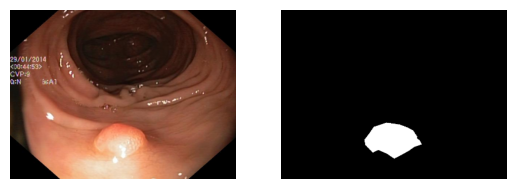

In [183]:
a = 10
plt.figure()
plt.subplot(121),plt.imshow(img_png_c[a])
plt.axis('off')
plt.subplot(122),plt.imshow(mask_c[a],'gray')
plt.axis('off')

(-0.5, 383.5, 287.5, -0.5)

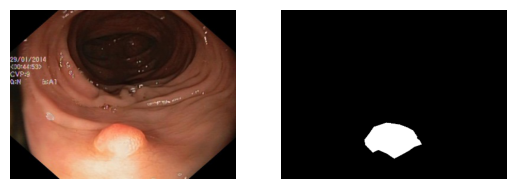

In [184]:
a = 10
plt.figure()
plt.subplot(121),plt.imshow(img_png_c1[a])
plt.axis('off')
plt.subplot(122),plt.imshow(mask_c1[a],'gray')
plt.axis('off')

In [75]:
import tensorflow as tf

def bce_jaccard_loss(y_true, y_pred, smooth=1e-7, alpha=0.5):
    """
    参数说明：
    - y_true: 真实标签 (shape=[batch, H, W, 1])
    - y_pred: 模型预测值 (shape=[batch, H, W, 1])
    - smooth: 防止除零的小常数
    - alpha: 平衡 BCE 和 Jaccard 的权重（默认 0.5）
    """
    # 计算二元交叉熵
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    
    # 计算 Jaccard Loss (IoU Loss)  
    y_true_f = tf.keras.backend.flatten(y_true)   # 展平为向量 [batch*H*W]
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f + y_pred_f) - intersection
    jaccard = (intersection + smooth) / (union + smooth)
    jaccard_loss = 1 - jaccard  # 将 IoU 转换为 Loss
    
    # 加权组合
    return alpha * bce + (1 - alpha) * jaccard_loss

In [76]:
def dice_score(y_true, y_pred, smooth=1e-7):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    denominator = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f)
    return (2.0 * intersection + smooth) / (denominator + smooth)

In [77]:
# def iou_score(y_true, y_pred, smooth=1e-7):
#     y_true_f = tf.keras.backend.flatten(y_true)
#     y_pred_f = tf.keras.backend.flatten(y_pred)
#     intersection = tf.reduce_sum(y_true_f * y_pred_f)
#     union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
#     return (intersection + smooth) / (union + smooth)

In [78]:
model.compile(
    optimizer='Adam',
    loss=bce_jaccard_loss,  # 可替换为 iou_loss 或 bce_jaccard_loss
    metrics=[
        dice_score, 
        sm.metrics.iou_score
        # tf.keras.metrics.BinaryAccuracy()  # 可选：添加准确率指标
    ]
)

In [185]:
# # 加载模型
model.load_weights(r'E:\paper1\best weight\2.different mode\TransUNet\img\bestweigh_epoch_068_val_iou_0.6763.h5', by_name=True)

In [186]:
# 评估模型（返回 loss + metrics）
results = model.evaluate(img_png_c, mask_c, verbose=0)

In [187]:
# 打印所有指标名称和值
print("\n=== 测试结果 ===")
print(f"Loss: {results[0]:.4f}")
print(f"dice_score: {results[1]:.4f}")
print(f"iou_score: {results[2]:.4f}")


=== 测试结果 ===
Loss: 0.3232
dice_score: 0.8247
iou_score: 0.7025


In [188]:
# # 加载模型
model.load_weights(r'E:\paper1\best weight\2.different mode\TransUNet\FMM+percentile=99.5\bestweigh_epoch_047_val_iou_0.6703.h5', by_name=True)

In [189]:
# 新方法评估模型（返回 loss + metrics）
results1 = model.evaluate(img_png_c1, mask_c1, verbose=0)

In [190]:
# 打印所有指标名称和值
print("\n=== 测试结果 ===")
print(f"Loss: {results1[0]:.4f}")
print(f"dice_score: {results1[1]:.4f}")
print(f"iou_score: {results1[2]:.4f}")


=== 测试结果 ===
Loss: 0.3096
dice_score: 0.8257
iou_score: 0.7038


In [191]:
# # 加载模型
model.load_weights(r'E:\paper1\best weight\2.different mode\TransUNet\img\bestweigh_epoch_068_val_iou_0.6763.h5', by_name=True)

In [192]:
#测试mask
imgp = model.predict(img_png_c, verbose=1)

4/4 [==============================] - 1s 125ms/step


In [193]:
# # 加载模型
model.load_weights(r'E:\paper1\best weight\2.different mode\TransUNet\FMM+percentile=99.5\bestweigh_epoch_047_val_iou_0.6703.h5', by_name=True)

In [194]:
#测试mask
imgp1 = model.predict(img_png_c1, verbose=1)

4/4 [==============================] - 0s 120ms/step


In [197]:
import time
from tqdm import tqdm
import os
import cv2

file_path = os.path.join(os.getcwd(), r'E:\paper1\TransUNet-output\Kvasir\FMM+percentile=99.5')
os.makedirs(file_path, exist_ok=True)  # 确保目录存在

# 保存图片
for i in tqdm(range(len(imgp1)), desc="保存图片"):
    # 生成文件名：img_序号.png
    filename = f"Kvasir-img_{i}.png"
    save_path = os.path.join(file_path, filename)
    # img1 = img_png_c1[...,::-1]
    # 保存图片
    cv2.imwrite(save_path, imgp1[i]*255)

print("恭喜，运行完成！已保存 {} 张图片".format(len(imgp1)))

保存图片: 100%|██████████| 100/100 [00:00<00:00, 411.31it/s]

恭喜，运行完成！已保存 100 张图片


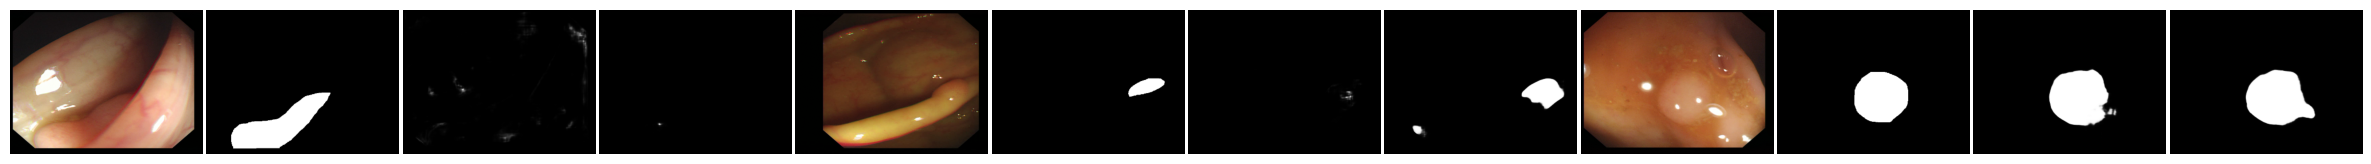

In [20]:
a, b, c = 8, 117, 311

# 设置更大的画布和紧凑布局
plt.figure(figsize=(24, 6))  # 宽度增加，高度适当调整
plt.subplots_adjust(wspace=0.02, 
                    left=0.01, 
                    right=0.99, 
                    top=0.5, 
                    bottom=0.05)  # 调整左右边距和子图间距

# 第1组子图
plt.subplot(1,12,1)
plt.imshow(img_png_c[a])
plt.axis('off')
plt.subplot(1,12,2)
plt.imshow(mask_c[a], 'gray')
plt.axis('off')
plt.subplot(1,12,3)
plt.imshow(imgp[a].reshape(288, 384), cmap='gray')
plt.axis('off')
plt.subplot(1,12,4)
plt.imshow(imgp1[a].reshape(288, 384), cmap='gray')
plt.axis('off')
# 第2组子图
plt.subplot(1,12,5)
plt.imshow(img_png_c[b])
plt.axis('off')
plt.subplot(1,12,6)
plt.imshow(mask_c[b], 'gray')
plt.axis('off')
plt.subplot(1,12,7)
plt.imshow(imgp[b].reshape(288, 384), cmap='gray')
plt.axis('off')
plt.subplot(1,12,8)
plt.imshow(imgp1[b].reshape(288, 384), cmap='gray')
plt.axis('off')
# 第3组子图
plt.subplot(1,12,9)
plt.imshow(img_png_c[c])
plt.axis('off')
plt.subplot(1,12,10)
plt.imshow(mask_c[c], 'gray')
plt.axis('off')
plt.subplot(1,12,11)
plt.imshow(imgp[c].reshape(288, 384), cmap='gray')
plt.axis('off')
plt.subplot(1,12,12)
plt.imshow(imgp1[c].reshape(288, 384), cmap='gray')
plt.axis('off')

plt.show()

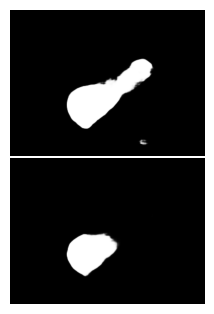

In [31]:
a = 4
# 创建紧凑画布
fig = plt.figure(figsize=(6, 3))

# 使用GridSpec控制微小边距
gs = fig.add_gridspec(2, 1, 
                     hspace=0.02,  # 行间距
                     left=0.01,    # 左边距
                     right=0.99,   # 右边距
                     top=0.99,     # 上边距
                     bottom=0.01)  # 下边距

# 添加图像子图
ax1 = fig.add_subplot(gs[0])
ax1.imshow(imgp[a].reshape(288, 384), 'gray')
ax1.axis('off')
ax1.margins(0.01)  # 图像周围微小边距

ax2 = fig.add_subplot(gs[1])
ax2.imshow(imgp1[a].reshape(288, 384), 'gray')
ax2.axis('off')
ax2.margins(0.01)  # 图像周围微小边距

# 显示紧凑布局
plt.show()